# Chapter 5: The Beer Game and the Cost of Local Rationality

*Systems Thinking with AI* by Jason Karpeles

Four sensible ordering desks, joined by delays, make a swing no desk intended.

**Goal.** Four views of the chapter's beer game chain. Compute one station's order, watch demand beliefs lag a step, see the order swing grow from retailer to factory as the delays lengthen, and test the supply-line fix whose largest gain lands at the factory.

**Demonstrations**

1. One station's order, with and without the supply line
2. Expected demand lags a step in orders
3. A four-case step grows at every station upstream
4. The supply-line fix lands three stations away

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/05-beer-game/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/05-beer-game/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_05_beer_game/code/amplification.py`

In [2]:
%%module chapters.chapter_05_beer_game.code.amplification
"""Measure how much larger a stage's order swing is than the customer's."""

import statistics


def swing(series: list[float]) -> float:
    """Peak-to-trough range of a series."""
    if not series:
        raise ValueError("series must not be empty")
    return max(series) - min(series)


def amplification_ratio(customer_orders: list[float], stage_orders: list[float]) -> float:
    """Return the stage's order swing divided by the customer's.

    A ratio above 1.0 means the stage ordered more erratically than its customer did.
    The beer game's central observation is that this ratio grows with distance upstream.
    """
    base = swing(customer_orders)
    if base <= 0.0:
        raise ValueError("customer orders must vary for amplification to be defined")
    return swing(stage_orders) / base


def stage_variability(history: dict[str, list[list[float]]]) -> list[float]:
    """Standard deviation of each stage's order stream, retailer first."""
    orders = history["orders"]
    return [statistics.pstdev([week[i] for week in orders]) for i in range(len(orders[0]))]


`chapters/chapter_05_beer_game/code/models.py`

In [3]:
%%module chapters.chapter_05_beer_game.code.models
"""State and parameters for one stage of a four-stage distribution chain."""

from dataclasses import dataclass, field

STAGE_NAMES = ("retailer", "wholesaler", "distributor", "factory")


@dataclass
class Stage:
    """One link in the chain: what it holds, what it owes, and what is in transit to it."""

    inventory: float = 12.0
    backlog: float = 0.0
    expected_demand: float = 4.0
    order_pipeline: list[float] = field(default_factory=lambda: [4.0, 4.0])
    shipment_pipeline: list[float] = field(default_factory=lambda: [4.0, 4.0])

    def supply_line(self, supplier_backlog: float) -> float:
        """Orders in transit, unfilled at the supplier, or shipped but not received.

        The caller supplies the upstream backlog owed to this stage. The factory
        uses zero because its external production source has unlimited capacity.
        """
        if supplier_backlog < 0:
            raise ValueError("supplier_backlog must be nonnegative")
        return sum(self.order_pipeline) + supplier_backlog + sum(self.shipment_pipeline)


@dataclass
class ChainParameters:
    """One policy, applied identically at every stage."""

    target_inventory: float = 12.0
    inventory_adjustment_time: float = 4.0
    supply_line_weight: float = 0.0
    demand_smoothing_time: float = 4.0
    pipeline_weeks: int = 2  # weeks of delay in each direction, order and shipment

    def __post_init__(self) -> None:
        if self.pipeline_weeks < 1:
            raise ValueError("pipeline_weeks must be at least 1")


`chapters/chapter_05_beer_game/code/validate_number.py`

In [4]:
%%module chapters.chapter_05_beer_game.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_05_beer_game/code/policy.py`

In [5]:
%%module chapters.chapter_05_beer_game.code.policy
"""The ordering rule each stage applies using only what it can see."""

from .validate_number import validate_number


def smooth_demand(expected: float, observed: float, smoothing_time: float) -> float:
    """Update a stage's belief about demand by closing part of the gap to what it just saw."""
    for value, name in ((expected, "expected"), (observed, "observed")):
        validate_number(value, name)
    validate_number(smoothing_time, "smoothing_time")
    if smoothing_time <= 0:
        raise ValueError("smoothing_time must be positive")
    return expected + (observed - expected) / smoothing_time


def order_quantity(
    expected_demand: float,
    inventory: float,
    backlog: float,
    supply_line: float,
    target_inventory: float,
    inventory_adjustment_time: float,
    supply_line_weight: float = 0.0,
) -> float:
    """Replace expected demand, correct the inventory gap, and discount the supply line.

    `supply_line_weight` is the whole experiment. At 0.0 the stage ignores what it has
    already ordered and re-orders to fix a gap that existing orders will fix on their own.
    At 1.0 it credits the supply line in full.
    """
    for value, name in (
        (expected_demand, "expected_demand"),
        (inventory, "inventory"),
        (backlog, "backlog"),
        (supply_line, "supply_line"),
        (target_inventory, "target_inventory"),
        (supply_line_weight, "supply_line_weight"),
    ):
        validate_number(value, name)
    validate_number(inventory_adjustment_time, "inventory_adjustment_time")
    if inventory_adjustment_time <= 0:
        raise ValueError("inventory_adjustment_time must be positive")
    if not 0.0 <= supply_line_weight <= 1.0:
        raise ValueError("supply_line_weight must lie between 0 and 1")

    effective_stock = inventory - backlog + supply_line_weight * supply_line
    gap = target_inventory - effective_stock
    order = expected_demand + gap / inventory_adjustment_time
    return order if order > 0.0 else 0.0


`chapters/chapter_05_beer_game/code/chain.py`

In [6]:
%%module chapters.chapter_05_beer_game.code.chain
"""Advance the whole chain one week, reading every flow before writing any stock."""

from .models import STAGE_NAMES, ChainParameters, Stage
from .policy import order_quantity, smooth_demand


def ship(stage: Stage, requested: float) -> float:
    """Ship what is asked for, or everything on hand. What is missed becomes backlog."""
    owed = stage.backlog + requested
    shipped = owed if owed <= stage.inventory else stage.inventory
    return shipped


def step_chain(
    stages: list[Stage], customer_order: float, parameters: ChainParameters
) -> tuple[list[Stage], list[float]]:
    """Advance every stage by one week and return the new state plus the orders placed.

    Flows are computed from the state at the start of the week. Stocks are written
    afterwards, so the result does not depend on the order the stages are visited in.
    """
    if len(stages) != len(STAGE_NAMES):
        raise ValueError(f"expected {len(STAGE_NAMES)} stages")

    incoming = [customer_order] + [stage.order_pipeline[0] for stage in stages[:-1]]
    arrivals = [stage.shipment_pipeline[0] for stage in stages]
    shipped = [ship(stage, request) for stage, request in zip(stages, incoming, strict=True)]

    orders = []
    for i, (stage, observed) in enumerate(zip(stages, incoming, strict=True)):
        expected = smooth_demand(stage.expected_demand, observed, parameters.demand_smoothing_time)
        orders.append(
            order_quantity(
                expected_demand=expected,
                inventory=stage.inventory,
                backlog=stage.backlog,
                supply_line=stage.supply_line(
                    stages[i + 1].backlog if i + 1 < len(stages) else 0.0
                ),
                target_inventory=parameters.target_inventory,
                inventory_adjustment_time=parameters.inventory_adjustment_time,
                supply_line_weight=parameters.supply_line_weight,
            )
        )

    updated = []
    for i, stage in enumerate(stages):
        upstream_shipment = shipped[i + 1] if i + 1 < len(stages) else stage.order_pipeline[0]
        updated.append(
            Stage(
                inventory=stage.inventory + arrivals[i] - shipped[i],
                backlog=stage.backlog + incoming[i] - shipped[i],
                expected_demand=smooth_demand(
                    stage.expected_demand, incoming[i], parameters.demand_smoothing_time
                ),
                order_pipeline=stage.order_pipeline[1:] + [orders[i]],
                shipment_pipeline=stage.shipment_pipeline[1:] + [upstream_shipment],
            )
        )
    return updated, orders


def run_chain(
    customer_demand: list[float], parameters: ChainParameters | None = None
) -> dict[str, list[list[float]]]:
    """Run the chain over a demand history and return every stage's weekly record."""
    if not customer_demand:
        raise ValueError("customer_demand must not be empty")
    parameters = parameters or ChainParameters()
    weeks = parameters.pipeline_weeks
    stages = [
        Stage(order_pipeline=[4.0] * weeks, shipment_pipeline=[4.0] * weeks) for _ in STAGE_NAMES
    ]
    history: dict[str, list[list[float]]] = {"inventory": [], "backlog": [], "orders": []}
    for demand in customer_demand:
        history["inventory"].append([s.inventory for s in stages])
        history["backlog"].append([s.backlog for s in stages])
        stages, orders = step_chain(stages, demand, parameters)
        history["orders"].append(orders)
    return history


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [7]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [8]:
"""Chapter 5 reader: the beer game, one ordering rule at a time.

Every number comes from the Chapter 5 pack (order_quantity, smooth_demand, run_chain,
amplification_ratio) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_05_beer_game.code.amplification import amplification_ratio, swing
from chapters.chapter_05_beer_game.code.chain import run_chain
from chapters.chapter_05_beer_game.code.models import STAGE_NAMES, ChainParameters
from chapters.chapter_05_beer_game.code.policy import order_quantity, smooth_demand

EQ_EFFECTIVE = "effective_stock = inventory - backlog + supply_line_weight * supply_line"
EQ_GAP = "gap   = target_inventory - effective_stock"
EQ_ORDER = "order = expected_demand + gap / inventory_adjustment_time"
EQ_SMOOTH = "expected + (observed - expected) / smoothing_time"
EQ_AMP = "amplification_ratio(demand, factory)"

DEMAND = [4.0] * 5 + [8.0] * 45
STATION_LABELS = ["Retailer", "Wholesaler", "Distributor", "Factory"]


def _factory_runs(weight, pipeline_weeks=2, adjustment_time=4.0):
    history = run_chain(
        DEMAND,
        ChainParameters(supply_line_weight=weight, pipeline_weeks=pipeline_weeks,
                        inventory_adjustment_time=adjustment_time),
    )
    streams = [[week[i] for week in history["orders"]] for i in range(len(STAGE_NAMES))]
    ratios = [amplification_ratio(DEMAND, s) for s in streams]
    return streams, ratios


# Demonstration 1: one station's ordering rule, with and without the supply line.

def ordering_rule(supply_line_weight=0.0, inventory_adjustment_time=4.0):
    expected, inventory, backlog, supply_line, target = 8.0, 6.0, 4.0, 24.0, 12.0
    w, t = float(supply_line_weight), float(inventory_adjustment_time)
    effective = inventory - backlog + w * supply_line
    gap = target - effective
    raw = expected + gap / t
    order = order_quantity(expected_demand=expected, inventory=inventory, backlog=backlog,
                           supply_line=supply_line, target_inventory=target,
                           inventory_adjustment_time=t, supply_line_weight=w)
    clamped = raw < 0

    fig, ax = new_figure()
    names = ["Expected demand", "Gap term", "Order placed"]
    values = [expected, gap / t, order]
    colors = [PALETTE["teal"], PALETTE["terracotta"] if gap / t >= 0 else PALETTE["olive"], PALETTE["navy"]]
    ax.bar(names, values, color=colors, width=0.55)
    ax.axhline(0, color=PALETTE["grey"], linewidth=1.2)
    for i, v in enumerate(values):
        ax.annotate(fmt(v, 1), (i, v), xytext=(0, 6 if v >= 0 else -16), textcoords="offset points",
                    ha="center", fontsize=11, color=PALETTE["ink"])
    ax.set_ylim(-18, 24)
    ax.set_xlabel("Terms of the ordering rule (cases per week)")
    ax.set_ylabel("Cases per week")

    metrics = {
        "Effective stock (cases)": fmt(effective, 1),
        "Gap (cases)": fmt(gap, 1),
        "Order before the floor (cases)": fmt(raw, 1),
        "Order placed (cases)": fmt(order, 1),
    }
    floor_note = (" The rule cannot order a negative amount, so the order is floored at 0." if clamped else "")
    interpretation = (
        f"Effective stock = 6 - 4 + {fmt(w, 1)} x 24 = {fmt(effective, 1)}. Gap = 12 - {signed(effective, 1)} = "
        f"{fmt(gap, 1)}. Order = 8 + {signed(gap, 1)} / {fmt(t, 0)} = {fmt(raw, 1)}.{floor_note} "
        f"{'Ignoring the supply line leaves a large gap, so the station orders again for goods already on their way.' if w == 0 else 'Crediting the supply line shrinks the gap, because goods already ordered will land on their own.'}"
    )
    return fig, metrics, interpretation


# Demonstration 2: expected demand is a belief that closes part of the gap each week.

def smoothing(smoothing_time=4.0, observed=8.0):
    weeks = 20
    expected = [4.0]
    for _ in range(weeks):
        expected.append(smooth_demand(expected[-1], observed, smoothing_time))
    full = [4.0]
    for _ in range(80):
        full.append(smooth_demand(full[-1], observed, smoothing_time))
    near = next((k for k, v in enumerate(full) if abs(observed - v) <= 1.0), None)

    fig, ax = new_figure()
    xs = np.arange(0, weeks + 1)
    ax.step([0, 0, weeks], [4.0, observed, observed], color=PALETTE["grey"], linewidth=1.6, linestyle="dashed")
    ax.plot(xs, expected, marker="o", markersize=4, color=PALETTE["navy"], linewidth=2)
    ax.set_xlim(0, weeks)
    ax.set_ylim(3, 13.5)
    label_point(ax, weeks, observed, f"Orders seen: {fmt(observed, 0)}", color=PALETTE["grey"], dx=-6, dy=8, ha="right")
    label_point(ax, weeks, expected[-1], "Expected demand", color=PALETTE["navy"], dx=-6, dy=-14, ha="right", va="top")
    ax.set_xlabel("Week after the step")
    ax.set_ylabel("Cases per week")

    first = expected[1]
    metrics = {
        "Smoothing time (weeks)": fmt(smoothing_time, 0),
        "Expected demand after week 1": fmt(first, 2),
        "Expected demand after week 4": fmt(expected[4], 2),
        f"Expected demand after week {weeks}": fmt(expected[-1], 2),
        "First week within 1 case of the orders seen": str(near) if near is not None else "not within 80 weeks",
    }
    gap = observed - 4.0
    interpretation = (
        f"Week 1: 4 + ({fmt(observed, 0)} - 4) / {fmt(smoothing_time, 0)} = 4 + {fmt(gap / smoothing_time, 2)} = "
        f"{fmt(first, 2)}. Each later week closes 1 / {fmt(smoothing_time, 0)} of the remaining gap. The belief "
        f"first comes within 1 case of the orders seen in week {near}, so a step in demand takes weeks to register."
        + (" With a smoothing time of 1 the belief jumps to the new level at once, which removes the lag." if smoothing_time == 1 else "")
    )
    return fig, metrics, interpretation


# Demonstration 3: the chain amplifies a four-case step more at each station upstream.

def chain_amplification(pipeline_weeks=2):
    streams, ratios = _factory_runs(0.0, pipeline_weeks=int(pipeline_weeks))
    factory = streams[3]
    weeks = np.arange(len(DEMAND))

    fig, (left, right) = new_figure(ncols=2)
    bars = left.bar(STATION_LABELS, ratios, color=[PALETTE["teal"], PALETTE["navy"], PALETTE["gold"], PALETTE["terracotta"]],
                    width=0.6)
    for rect, r in zip(bars, ratios):
        left.annotate(fmt(r, 1) + "x", (rect.get_x() + rect.get_width() / 2, r), xytext=(0, 5),
                      textcoords="offset points", ha="center", fontsize=10.5)
    left.set_ylim(0, 115)
    left.set_xlabel("Station, retailer to factory")
    left.set_ylabel("Order swing / customer swing")
    left.tick_params(axis="x", labelsize=10)
    left.set_title("Amplification", fontsize=11.5)

    right.step(weeks, DEMAND, where="post", color=PALETTE["grey"], linestyle="dashed", linewidth=1.6)
    right.plot(weeks, factory, color=PALETTE["terracotta"], linewidth=2)
    right.set_ylim(-5, 430)
    right.set_xlim(0, 49)
    label_point(right, 49, 8, "Customer", color=PALETTE["grey"], dx=-6, dy=10, ha="right")
    label_point(right, 20, max(factory), "Factory orders", color=PALETTE["terracotta"], dx=8, dy=-4, va="top")
    right.set_xlabel("Week")
    right.set_ylabel("Cases ordered per week")
    right.set_title("Factory orders", fontsize=11.5)

    low, high = min(factory), max(factory)
    metrics = {"Weeks of delay each way": int(pipeline_weeks)}
    for name, r in zip(STATION_LABELS, ratios):
        metrics[f"{name} order swing (x customer)"] = fmt(r, 1)
    metrics["Factory peak order (cases)"] = fmt(high, 0)
    interpretation = (
        f"The customer's swing is 8 - 4 = 4 cases. The factory's orders range from {fmt(low, 2)} to {fmt(high, 2)}, "
        f"a swing of {fmt(high, 2)} - {fmt(low, 2)} = {fmt(high - low, 2)}, so the ratio is {fmt(high - low, 2)} / 4 = "
        f"{fmt(ratios[3], 1)}. The ratio grows from {fmt(ratios[0], 1)} at the retailer to {fmt(ratios[3], 1)} at the "
        f"factory with {int(pipeline_weeks)} week(s) of delay each way, because each station's orders are the next "
        f"station's demand signal."
    )
    return fig, metrics, interpretation


# Demonstration 4: crediting the supply line helps the factory and not the retailer.

def supply_line_fix(supply_line_weight=1.0, inventory_adjustment_time=4.0):
    w, t = float(supply_line_weight), float(inventory_adjustment_time)
    streams, ratios = _factory_runs(w, adjustment_time=t)
    _, base = _factory_runs(0.0, adjustment_time=t)

    fig, ax = new_figure()
    xs = np.arange(4)
    width = 0.36
    ax.bar(xs - width / 2, base, width, color=PALETTE["light"], edgecolor=PALETTE["grey"])
    ax.bar(xs + width / 2, ratios, width, color=PALETTE["navy"])
    for x, b, r in zip(xs, base, ratios):
        ax.annotate(fmt(b, 1), (x - width / 2, b), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10)
        ax.annotate(fmt(r, 1), (x + width / 2, r), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=10, color=PALETTE["navy"])
    ax.set_xticks(xs, STATION_LABELS)
    ax.tick_params(axis="x", labelsize=10)
    ax.set_ylim(0, max(max(base), max(ratios)) * 1.18)
    ax.set_xlabel("Station (grey: supply line ignored, blue: weight as chosen)")
    ax.set_ylabel("Order swing / customer swing")

    retailer_change = ratios[0] - base[0]
    factory_change = ratios[3] - base[3]
    metrics = {
        "Supply line weight": fmt(w, 1),
        "Inventory adjustment time (weeks)": fmt(t, 0),
        "Retailer swing, ignored then chosen": f"{fmt(base[0], 1)} then {fmt(ratios[0], 1)}",
        "Factory swing, ignored then chosen": f"{fmt(base[3], 1)} then {fmt(ratios[3], 1)}",
        "Factory peak order (cases)": fmt(max(streams[3]), 0),
    }
    if w == 0:
        verdict = "With weight 0 this is the baseline: both bars are the same."
    else:
        verdict = (f"The retailer's swing moves by {signed(retailer_change, 1)} and the factory's by "
                   f"{signed(factory_change, 1)}. "
                   + ("The retailer sees no gain from the change while the factory three stations away does."
                      if retailer_change >= 0 and factory_change < 0 else
                      "Here the change helps at both ends."))
    interpretation = (
        f"Effective stock = inventory - backlog + {fmt(w, 1)} x supply line. Factory swing: "
        f"{fmt(ratios[3], 1)} - {fmt(base[3], 1)} = {signed(factory_change, 1)}. Retailer swing: "
        f"{fmt(ratios[0], 1)} - {fmt(base[0], 1)} = {signed(retailer_change, 1)}. {verdict}"
    )
    return fig, metrics, interpretation


## 1. One station's order, with and without the supply line

*How much of an order is a reaction to goods that are already on their way?*

The order is the expected demand plus a correction: the gap between target and effective stock, spread over the adjustment time. A weight of 0 leaves the supply line out of effective stock, so the gap looks large and the correction is large.

    effective_stock = inventory - backlog + supply_line_weight * supply_line
    gap   = target_inventory - effective_stock
    order = expected_demand + gap / inventory_adjustment_time

**Symbols and inputs.** Cases are the unit. The station expects 8 cases a week, holds 6 in inventory, owes 4 in backlog, has 24 cases ordered or in transit (the supply line) and wants 12 on hand. supply_line_weight is how much of the supply line it credits.

**Predict first.** With a weight of 0 and an adjustment time of 4 weeks, does the station order more or less than the 8 cases it expects to sell?

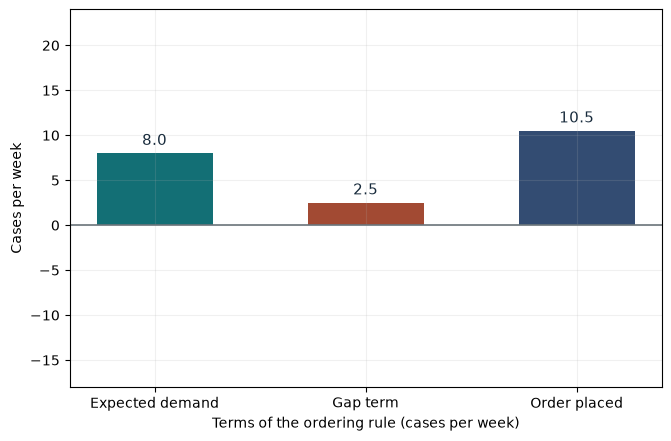

- **Effective stock (cases):** 2.0
- **Gap (cases):** 10.0
- **Order before the floor (cases):** 10.5
- **Order placed (cases):** 10.5

Effective stock = 6 - 4 + 0.0 x 24 = 2.0. Gap = 12 - 2.0 = 10.0. Order = 8 + 10.0 / 4 = 10.5. Ignoring the supply line leaves a large gap, so the station orders again for goods already on their way.

In [9]:
show(ordering_rule(supply_line_weight=0.0, inventory_adjustment_time=4.0))

**Use the idea.** When a rule orders, hires or builds to close a gap, ask whether the gap already counts what has been committed but has not arrived.

**Where the conclusion applies.** One station in one week with the state defined above. The rule floors the order at zero; a station that also returns goods would need a different rule.

*Constructed example: the chapter's ordering rule applied to a station state defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(ordering_rule, [('supply_line_weight', [0.0, 0.5, 1.0]), ('inventory_adjustment_time', [1.0, 4.0])])

- **supply_line_weight = 0.0, inventory_adjustment_time = 1.0**: Effective stock (cases) 2.0; Gap (cases) 10.0; Order before the floor (cases) 18.0; Order placed (cases) 18.0
- **supply_line_weight = 0.0, inventory_adjustment_time = 4.0**: Effective stock (cases) 2.0; Gap (cases) 10.0; Order before the floor (cases) 10.5; Order placed (cases) 10.5
- **supply_line_weight = 0.5, inventory_adjustment_time = 1.0**: Effective stock (cases) 14.0; Gap (cases) -2.0; Order before the floor (cases) 6.0; Order placed (cases) 6.0
- **supply_line_weight = 0.5, inventory_adjustment_time = 4.0**: Effective stock (cases) 14.0; Gap (cases) -2.0; Order before the floor (cases) 7.5; Order placed (cases) 7.5
- **supply_line_weight = 1.0, inventory_adjustment_time = 1.0**: Effective stock (cases) 26.0; Gap (cases) -14.0; Order before the floor (cases) -6.0; Order placed (cases) 0.0
- **supply_line_weight = 1.0, inventory_adjustment_time = 4.0**: Effective stock (cases) 26.0; Gap (cases) -14.0; Order before the floor (cases) 4.5; Order placed (cases) 4.5

## 2. Expected demand lags a step in orders

*How long does a station take to believe that demand has really changed?*

Each week the belief moves 1 / smoothing_time of the way to what was observed. The gap shrinks by the same fraction each week, so the belief approaches the new level but never jumps to it unless the smoothing time is 1.

    expected + (observed - expected) / smoothing_time

**Symbols and inputs.** expected is the station's belief about weekly demand, observed is the order it just saw, and smoothing_time is how many weeks of the gap to close at once. Cases per week.

**Predict first.** With a smoothing time of 8 weeks and orders jumping from 4 to 8, is the belief above 6 after 4 weeks?

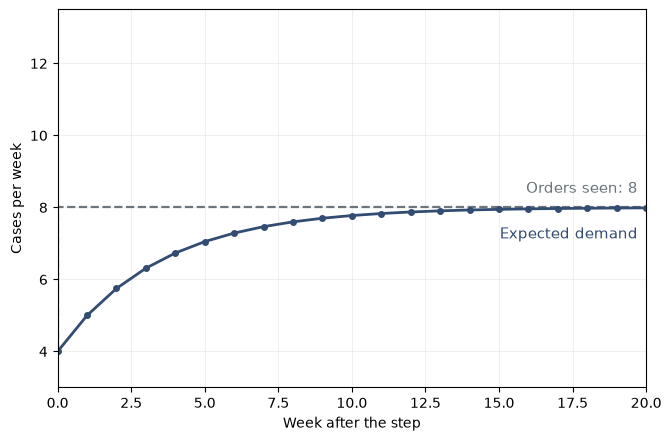

- **Smoothing time (weeks):** 4
- **Expected demand after week 1:** 5.00
- **Expected demand after week 4:** 6.73
- **Expected demand after week 20:** 7.99
- **First week within 1 case of the orders seen:** 5

Week 1: 4 + (8 - 4) / 4 = 4 + 1.00 = 5.00. Each later week closes 1 / 4 of the remaining gap. The belief first comes within 1 case of the orders seen in week 5, so a step in demand takes weeks to register.

In [11]:
show(smoothing(smoothing_time=4.0, observed=8.0))

**Use the idea.** A forecast that is updated gradually is a delay. Treat its smoothing time as a delay length when you reason about stability.

**Where the conclusion applies.** The belief starts at 4 and the orders seen stay constant after the step. If orders keep changing, the belief trails them.

*Constructed example: the chapter's smoothing rule with its four-week default, started at 4 cases a week and stepped to 8 or 12.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(smoothing, [('smoothing_time', [1.0, 2.0, 4.0, 8.0]), ('observed', [8.0, 12.0])])

- **smoothing_time = 1.0, observed = 8.0**: Smoothing time (weeks) 1; Expected demand after week 1 8.00; Expected demand after week 4 8.00; Expected demand after week 20 8.00; First week within 1 case of the orders seen 1
- **smoothing_time = 1.0, observed = 12.0**: Smoothing time (weeks) 1; Expected demand after week 1 12.00; Expected demand after week 4 12.00; Expected demand after week 20 12.00; First week within 1 case of the orders seen 1
- **smoothing_time = 2.0, observed = 8.0**: Smoothing time (weeks) 2; Expected demand after week 1 6.00; Expected demand after week 4 7.75; Expected demand after week 20 8.00; First week within 1 case of the orders seen 2
- **smoothing_time = 2.0, observed = 12.0**: Smoothing time (weeks) 2; Expected demand after week 1 8.00; Expected demand after week 4 11.50; Expected demand after week 20 12.00; First week within 1 case of the orders seen 3
- **smoothing_time = 4.0, observed = 8.0**: Smoothing time (weeks) 4; Expected demand after week 1 5.00; Expected demand after week 4 6.73; Expected demand after week 20 7.99; First week within 1 case of the orders seen 5
- **smoothing_time = 4.0, observed = 12.0**: Smoothing time (weeks) 4; Expected demand after week 1 6.00; Expected demand after week 4 9.47; Expected demand after week 20 11.97; First week within 1 case of the orders seen 8
- **smoothing_time = 8.0, observed = 8.0**: Smoothing time (weeks) 8; Expected demand after week 1 4.50; Expected demand after week 4 5.66; Expected demand after week 20 7.72; First week within 1 case of the orders seen 11
- **smoothing_time = 8.0, observed = 12.0**: Smoothing time (weeks) 8; Expected demand after week 1 5.00; Expected demand after week 4 7.31; Expected demand after week 20 11.45; First week within 1 case of the orders seen 16

## 3. A four-case step grows at every station upstream

*How much larger is each station's order swing than the customer's, and what does delay length do to it?*

Each station's order stream is the next station's demand signal, and each station adds its own correction on top. Longer pipelines mean each correction lands later, so the swing grows steeply with delay length.

    amplification_ratio(demand, factory)

**Symbols and inputs.** The customer orders 4 cases a week for 5 weeks, then 8 for 45 weeks. A station's swing is its highest weekly order minus its lowest. The ratio divides that by the customer's swing of 4. pipeline_weeks is the delay in each direction.

**Predict first.** With two weeks of delay each way, does the factory's swing exceed 30 times the customer's?

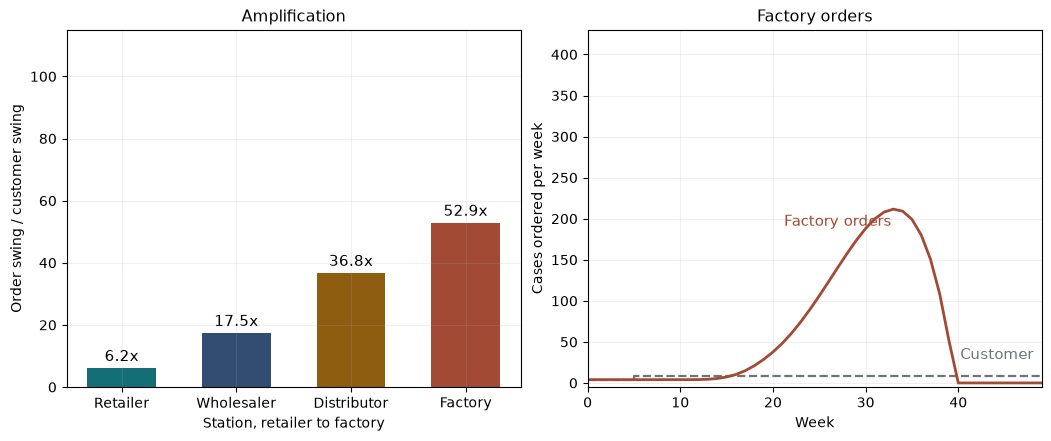

- **Weeks of delay each way:** 2
- **Retailer order swing (x customer):** 6.2
- **Wholesaler order swing (x customer):** 17.5
- **Distributor order swing (x customer):** 36.8
- **Factory order swing (x customer):** 52.9
- **Factory peak order (cases):** 212

The customer's swing is 8 - 4 = 4 cases. The factory's orders range from 0.00 to 211.63, a swing of 211.63 - 0.00 = 211.63, so the ratio is 211.63 / 4 = 52.9. The ratio grows from 6.2 at the retailer to 52.9 at the factory with 2 week(s) of delay each way, because each station's orders are the next station's demand signal.

In [13]:
show(chain_amplification(pipeline_weeks=2))

**Use the idea.** A chain's exposure is mostly a property of its delays. Measure the delay before blaming the people who order.

**Where the conclusion applies.** Identical stations, a single step in demand, the supply line ignored, orders floored at zero and a 50 week run. With four weeks of delay the factory is still ordering heavily at week 50, so its swing is measured on that window. A chain with different policies at each station would give different ratios.

*Constructed example: the chapter's four-station chain and its 4-to-8 step, run with one to four weeks of delay.*

Every setting the interactive reader offers for this demonstration:

In [14]:
sweep(chain_amplification, [('pipeline_weeks', [1, 2, 3, 4])])

- **pipeline_weeks = 1**: Weeks of delay each way 1; Retailer order swing (x customer) 4.2; Wholesaler order swing (x customer) 8.6; Distributor order swing (x customer) 14.5; Factory order swing (x customer) 18.2; Factory peak order (cases) 73
- **pipeline_weeks = 2**: Weeks of delay each way 2; Retailer order swing (x customer) 6.2; Wholesaler order swing (x customer) 17.5; Distributor order swing (x customer) 36.8; Factory order swing (x customer) 52.9; Factory peak order (cases) 212
- **pipeline_weeks = 3**: Weeks of delay each way 3; Retailer order swing (x customer) 8.2; Wholesaler order swing (x customer) 29.0; Distributor order swing (x customer) 70.5; Factory order swing (x customer) 112.3; Factory peak order (cases) 449
- **pipeline_weeks = 4**: Weeks of delay each way 4; Retailer order swing (x customer) 9.2; Wholesaler order swing (x customer) 42.1; Distributor order swing (x customer) 116.5; Factory order swing (x customer) 201.1; Factory peak order (cases) 808

## 4. The supply-line fix lands three stations away

*If every station credits what it has already ordered, who benefits?*

Counting the supply line removes the repeat orders that cause the later stations to overshoot, which shrinks swings most far upstream. In this chain the retailer's swing also falls, from 6.2 to 2.1 times the customer's, but that is a chain-wide change, not the result of changing the retailer's rule alone.

    effective_stock = inventory - backlog + supply_line_weight * supply_line
    amplification_ratio(demand, factory)

**Symbols and inputs.** supply_line_weight runs from 0 (ignore the supply line) to 1 (credit it in full). The inventory adjustment time is how many weeks a station takes to close its inventory gap. Swing ratios are as in the previous demonstration.

**Predict first.** At weight 1 and an adjustment time of 4 weeks, does the retailer's swing fall or rise?

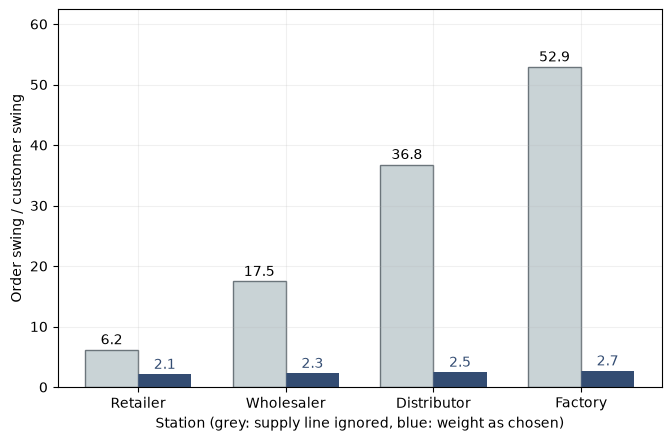

- **Supply line weight:** 1.0
- **Inventory adjustment time (weeks):** 4
- **Retailer swing, ignored then chosen:** 6.2 then 2.1
- **Factory swing, ignored then chosen:** 52.9 then 2.7
- **Factory peak order (cases):** 11

Effective stock = inventory - backlog + 1.0 x supply line. Factory swing: 2.7 - 52.9 = (-50.2). Retailer swing: 2.1 - 6.2 = (-4.1). The retailer's swing moves by (-4.1) and the factory's by (-50.2). Here the change helps at both ends.

In [15]:
show(supply_line_fix(supply_line_weight=1.0, inventory_adjustment_time=4.0))

**Use the idea.** A change can look unhelpful from every seat inside a system and still be right for the system. That is the case for modelling the whole chain.

**Where the conclusion applies.** Two-week delays, a 4-to-8 step and identical policies at every station. Counting every outstanding order against the same target leaves less stock to cover delays, so backlog can persist, as the chapter's backlog table shows.

*Constructed example: the chapter's weight 0 and weight 1 runs, plus a weight of 0.5 and a one-week adjustment time defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [16]:
sweep(supply_line_fix, [('supply_line_weight', [0.0, 0.5, 1.0]), ('inventory_adjustment_time', [4.0, 1.0])])

- **supply_line_weight = 0.0, inventory_adjustment_time = 4.0**: Supply line weight 0.0; Inventory adjustment time (weeks) 4; Retailer swing, ignored then chosen 6.2 then 6.2; Factory swing, ignored then chosen 52.9 then 52.9; Factory peak order (cases) 212
- **supply_line_weight = 0.0, inventory_adjustment_time = 1.0**: Supply line weight 0.0; Inventory adjustment time (weeks) 1; Retailer swing, ignored then chosen 17.2 then 17.2; Factory swing, ignored then chosen 1071.4 then 1071.4; Factory peak order (cases) 4285
- **supply_line_weight = 0.5, inventory_adjustment_time = 4.0**: Supply line weight 0.5; Inventory adjustment time (weeks) 4; Retailer swing, ignored then chosen 6.2 then 3.3; Factory swing, ignored then chosen 52.9 then 9.6; Factory peak order (cases) 38
- **supply_line_weight = 0.5, inventory_adjustment_time = 1.0**: Supply line weight 0.5; Inventory adjustment time (weeks) 1; Retailer swing, ignored then chosen 17.2 then 3.9; Factory swing, ignored then chosen 1071.4 then 27.0; Factory peak order (cases) 108
- **supply_line_weight = 1.0, inventory_adjustment_time = 4.0**: Supply line weight 1.0; Inventory adjustment time (weeks) 4; Retailer swing, ignored then chosen 6.2 then 2.1; Factory swing, ignored then chosen 52.9 then 2.7; Factory peak order (cases) 11
- **supply_line_weight = 1.0, inventory_adjustment_time = 1.0**: Supply line weight 1.0; Inventory adjustment time (weeks) 1; Retailer swing, ignored then chosen 17.2 then 2.2; Factory swing, ignored then chosen 1071.4 then 2.9; Factory peak order (cases) 12

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With a weight of 0.5 and an adjustment time of 4 weeks, what does the station order?

<details><summary>Answer</summary>

Effective stock = 6 - 4 + 0.5 x 24 = 14. Gap = 12 - 14 = -2. Order = 8 + (-2) / 4 = 7.5 cases.

</details>

### Exercise 2

With a smoothing time of 2 and orders of 8 after a start of 4, what is the belief after week 2?

<details><summary>Answer</summary>

Week 1: 4 + (8 - 4) / 2 = 6. Week 2: 6 + (8 - 6) / 2 = 7.

</details>

### Exercise 3

If the factory's orders ranged from 0 to 140 cases and the customer's swing is 4, what would the ratio be?

<details><summary>Answer</summary>

140 / 4 = 35. The two-week run here gives 211.63 / 4 = 52.9.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/